# ML Models with PCA Optimization
## Phase 2: Optimization - Dimensionality Reduction



### Models:
1. Random Forest (RF)
2. Decision Tree (DT)
3. XGBoost ⭐ Best performer
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Naive Bayes (NB)

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, balanced_accuracy_score)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Configuration

In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml_optimized/pca/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PCA CONFIGURATION
# ========================================
# Option 1: Set number of components directly
N_COMPONENTS = 30  # Reduce 59 features to 30 principal components

# Option 2: Set variance to retain (uncomment to use)
# N_COMPONENTS = 0.95  # Retain 95% of variance

print(f"🎯 PCA Configuration: {N_COMPONENTS} components")

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset ⭐ BEST MODEL
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("\n📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    marker = ' ⭐' if model == 'XGBoost' else ''
    print(f"   {model}: {size_str}{marker}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")
print(f"\n🎯 Optimization: PCA (Principal Component Analysis)")

🎯 PCA Configuration: 30 components

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset ⭐
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml_optimized/pca/

🎯 Optimization: PCA (Principal Component Analysis)


## 3️⃣ Load Dataset

In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

chunks = []
total_rows = 0

print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

## 4️⃣ Prepare Features and Target

In [4]:
# ========================================
# SEPARATE FEATURES AND TARGET
# ========================================

label_columns = ['Label', 'Label_Binary']
existing_labels = [col for col in label_columns if col in df_full.columns]

X_full = df_full.drop(columns=existing_labels)
y_full = df_full['Label_Binary']

print(f"✅ Features (X): {X_full.shape}")
print(f"✅ Target (y): {y_full.shape}")
print(f"\n📊 Original features: {X_full.shape[1]}")
print(f"📊 After PCA: {N_COMPONENTS} components (reduction: {X_full.shape[1] - N_COMPONENTS} features)")

✅ Features (X): (16232943, 57)
✅ Target (y): (16232943,)

📊 Original features: 57
📊 After PCA: 30 components (reduction: 27 features)


## 5️⃣ Define Models

In [5]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=1),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbosity=1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE, verbose=True),
    'Naive Bayes': GaussianNB()
}

print(f"✅ Defined {len(models)} models")

✅ Defined 6 models


## 6️⃣ Helper Functions

In [6]:
def calculate_far(y_true, y_pred):
    """Calculate False Alert Rate: FAR = FP / (FP + TN)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    return far

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """Get train/test split with optional sampling"""
    if sample_size is None:
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            X, _, y, _ = train_test_split(
                X_full, y_full, 
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    print(f"🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test

## 7️⃣ Train and Evaluate Models with PCA

In [7]:
# ========================================
# TRAIN AND TEST ALL MODELS WITH PCA
# ========================================

results          = {}
trained_models   = {}
scalers          = {}
pca_transformers = {}

for model_name, model in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name} WITH PCA")
    print("="*80)

    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")

    sample_size = MODEL_SAMPLE_SIZES.get(model_name)

    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )

    # ── Step 1: Standardize ───────────────────────────────────────────────
    print(f"\n⚖️  Step 1/2: Standardizing features...")
    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"✅ Features standardized: mean=0, std=1")

    # ── Step 2: PCA ───────────────────────────────────────────────────────
    print(f"\n🔬 Step 2/2: Applying PCA...")
    print(f"   Original dimensions: {X_train_scaled.shape[1]}")

    pca          = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
    X_train_pca  = pca.fit_transform(X_train_scaled)
    X_test_pca   = pca.transform(X_test_scaled)

    print(f"   Reduced dimensions : {X_train_pca.shape[1]}")
    print(f"   Variance explained : {pca.explained_variance_ratio_.sum()*100:.2f}%")
    print(f"   Features removed   : {X_train_scaled.shape[1] - X_train_pca.shape[1]}")
    print(f"✅ PCA transformation complete")

    scalers[model_name]          = scaler
    pca_transformers[model_name] = pca

    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
            pickle.dump(scaler, f)
        with open(os.path.join(model_dir, 'pca.pkl'), 'wb') as f:
            pickle.dump(pca, f)
        print(f"💾 Scaler & PCA saved")

    # ── Train ─────────────────────────────────────────────────────────────
    print(f"\n⏱️  Training with PCA-reduced features...")
    start_time = time.time()
    model.fit(X_train_pca, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")

    # ── Predict ───────────────────────────────────────────────────────────
    print(f"\n🔮 Making predictions...")
    start_time = time.time()
    y_pred     = model.predict(X_test_pca)
    pred_time  = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")

    # ── Metrics ───────────────────────────────────────────────────────────
    accuracy         = accuracy_score(y_test, y_pred)
    f1_mac           = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc          = balanced_accuracy_score(y_test, y_pred)
    cm               = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp   = cm.ravel()
    benign_recall    = tn / (tn + fp) if (tn + fp) > 0 else 0
    attack_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    benign_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    attack_precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    # ── Print metrics ─────────────────────────────────────────────────────
    print(f"\n📊 RESULTS WITH PCA:")
    print(f"   Balanced Accuracy : {bal_acc:.4f}  ⭐ Primary metric")
    print(f"   F1 Macro          : {f1_mac:.4f}")
    print(f"   Benign Recall     : {benign_recall:.4f}")
    print(f"   Attack Recall     : {attack_recall:.4f}")
    print(f"   Benign Precision  : {benign_precision:.4f}")
    print(f"   Attack Precision  : {attack_precision:.4f}")
    print(f"   Accuracy (ref)    : {accuracy:.4f}  ⚠️  misleading on imbalanced data")
    print(f"   Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

    print(f"\n🕐 TIME:")
    print(f"   Train: {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"   Test:  {pred_time:.2f}s")

    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    print(f"   TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

    # ── Store results ─────────────────────────────────────────────────────
    results[model_name] = {
        'accuracy'          : accuracy,
        'balanced_accuracy' : bal_acc,
        'f1_macro'          : f1_mac,
        'benign_recall'     : benign_recall,
        'attack_recall'     : attack_recall,
        'benign_precision'  : benign_precision,
        'attack_precision'  : attack_precision,
        'confusion_matrix'  : cm,
        'train_time'        : train_time,
        'pred_time'         : pred_time,
        'sample_size'       : len(X_train) + len(X_test),
        'n_components'      : N_COMPONENTS,
        'variance_explained': pca.explained_variance_ratio_.sum()
    }

    trained_models[model_name] = model

    # ── Save ──────────────────────────────────────────────────────────────
    if SAVE_MODELS:
        with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
            pickle.dump(model, f)

        metadata = {
            'model_name'        : model_name,
            'sample_size'       : sample_size,
            'train_samples'     : len(X_train),
            'test_samples'      : len(X_test),
            'original_features' : X_train.shape[1],
            'pca_components'    : N_COMPONENTS,
            'variance_explained': pca.explained_variance_ratio_.sum(),
            'train_time'        : train_time,
            'metrics': {
                'balanced_accuracy': bal_acc,
                'f1_macro'         : f1_mac,
                'benign_recall'    : benign_recall,
                'attack_recall'    : attack_recall,
                'benign_precision' : benign_precision,
                'attack_precision' : attack_precision,
                'accuracy'         : accuracy,
            }
        }

        with open(os.path.join(model_dir, 'metadata.pkl'), 'wb') as f:
            pickle.dump(metadata, f)
        print(f"\n💾 Model & metadata saved")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED WITH PCA!")
print("="*80)


🚀 TRAINING: Random Forest WITH PCA
📁 Model directory: trained_models/ml_optimized/pca/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions : 30
   Variance explained : 99.77%
   Features removed   : 27
✅ PCA transformation complete
💾 Scaler & PCA saved

⏱️  Training with PCA-reduced features...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed: 10.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 37.2min finished


✅ Training completed in 2237.30 seconds (37.29 minutes)

🔮 Making predictions...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:   16.1s finished


✅ Predictions completed in 17.88 seconds

📊 RESULTS WITH PCA:
   Balanced Accuracy : 0.9713  ⭐ Primary metric
   F1 Macro          : 0.9780
   Benign Recall     : 0.9962
   Attack Recall     : 0.9464
   Benign Precision  : 0.9892
   Attack Precision  : 0.9807
   Accuracy (ref)    : 0.9878  ⚠️  misleading on imbalanced data
   Variance Explained: 99.77%

🕐 TIME:
   Train: 2237.30s (37.29 min)
   Test:  17.88s

🎯 Confusion Matrix:
[[2686714   10228]
 [  29450  520197]]
   TN=2,686,714  FP=10,228  FN=29,450  TP=520,197

💾 Model & metadata saved

🚀 TRAINING: Decision Tree WITH PCA
📁 Model directory: trained_models/ml_optimized/pca/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples

⚖️  Step 1/2: Standardizing features...
✅ Features standardized: mean=0, std=1

🔬 Step 2/2: Applying PCA...
   Original dimensions: 57
   Reduced dimensions : 30
   Variance explained : 99.77%
   Features 

## 8️⃣ Results Summary

In [9]:
print("\n" + "="*100)
print("📊 FINAL RESULTS SUMMARY - PCA Optimization")
print("="*100)

results_df = pd.DataFrame({
    'Model'             : list(results.keys()),
    'Balanced Accuracy' : [results[m]['balanced_accuracy']  for m in results],
    'F1 Macro'          : [results[m]['f1_macro']           for m in results],
    'Benign Recall'     : [results[m]['benign_recall']       for m in results],
    'Attack Recall'     : [results[m]['attack_recall']       for m in results],
    'Benign Precision'  : [results[m]['benign_precision']    for m in results],
    'Attack Precision'  : [results[m]['attack_precision']    for m in results],
    'Accuracy'          : [results[m]['accuracy']            for m in results],
    'Train Time (s)'    : [results[m]['train_time']          for m in results],
    'Variance Explained': [results[m]['variance_explained']  for m in results],
    'Samples'           : [results[m]['sample_size']         for m in results],
})
results_df = results_df.sort_values('Balanced Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy %']  = (results_df['Accuracy']           * 100).round(4)
results_df['Variance %']  = (results_df['Variance Explained'] * 100).round(2)
results_df['Time (min)']  = (results_df['Train Time (s)']     / 60).round(2)

print('\nRanked by Balanced Accuracy (primary metric):')
display(results_df[[
    'Model', 'Balanced Accuracy', 'F1 Macro',
    'Benign Recall', 'Attack Recall',
    'Benign Precision', 'Attack Precision',
    'Accuracy %', 'Variance %', 'Time (min)', 'Samples'
]].style.background_gradient(
    subset=['Balanced Accuracy', 'F1 Macro', 'Benign Recall', 'Attack Recall'],
    cmap='RdYlGn'
))

print('\n🏆 BEST PERFORMERS:')
best = results_df.iloc[0]
print(f"   Highest Balanced Accuracy : {best['Model']} — {best['Balanced Accuracy']:.4f}")
print(f"   Best Benign Recall        : {results_df.loc[results_df['Benign Recall'].idxmax(), 'Model']} — {results_df['Benign Recall'].max():.4f}")
print(f"   Best Attack Recall        : {results_df.loc[results_df['Attack Recall'].idxmax(), 'Model']} — {results_df['Attack Recall'].max():.4f}")

print('\n⚠️  NOTE: Balanced Accuracy is the primary metric — plain accuracy is misleading on imbalanced data.')
print('    Balanced Accuracy = (Benign Recall + Attack Recall) / 2')

results_path = os.path.join(BASE_MODEL_DIR, 'results_summary.csv')
results_df.to_csv(results_path, index=False)
print(f'\n💾 Results saved: {results_path}')


📊 FINAL RESULTS SUMMARY - PCA Optimization

Ranked by Balanced Accuracy (primary metric):


,Model,Balanced Accuracy,F1 Macro,Benign Recall,Attack Recall,Benign Precision,Attack Precision,Accuracy %,Variance %,Time (min),Samples
0,KNN,0.971330,0.979560,0.997592,0.945068,0.988902,0.987654,98.870000,99.840000,0.000000,50000
1,Random Forest,0.971314,0.977967,0.996208,0.946420,0.989158,0.980717,98.777900,99.770000,37.290000,16232943
2,XGBoost,0.971076,0.981812,0.999685,0.942467,0.988407,0.998362,98.999800,99.770000,0.600000,16232943
3,Decision Tree,0.970023,0.973261,0.992760,0.947286,0.989294,0.963852,98.506100,99.770000,25.110000,16232943
4,SVM,0.936374,0.958329,0.998856,0.873892,0.974915,0.993620,97.770000,99.820000,0.280000,100000
5,Naive Bayes,0.622718,0.383875,0.264258,0.981177,0.985691,0.213707,38.563200,99.770000,0.200000,16232943



🏆 BEST PERFORMERS:
   Highest Balanced Accuracy : KNN — 0.9713
   Best Benign Recall        : XGBoost — 0.9997
   Best Attack Recall        : Naive Bayes — 0.9812

⚠️  NOTE: Balanced Accuracy is the primary metric — plain accuracy is misleading on imbalanced data.
    Balanced Accuracy = (Benign Recall + Attack Recall) / 2

💾 Results saved: trained_models/ml_optimized/pca/results_summary.csv


## 9️⃣ Visualization

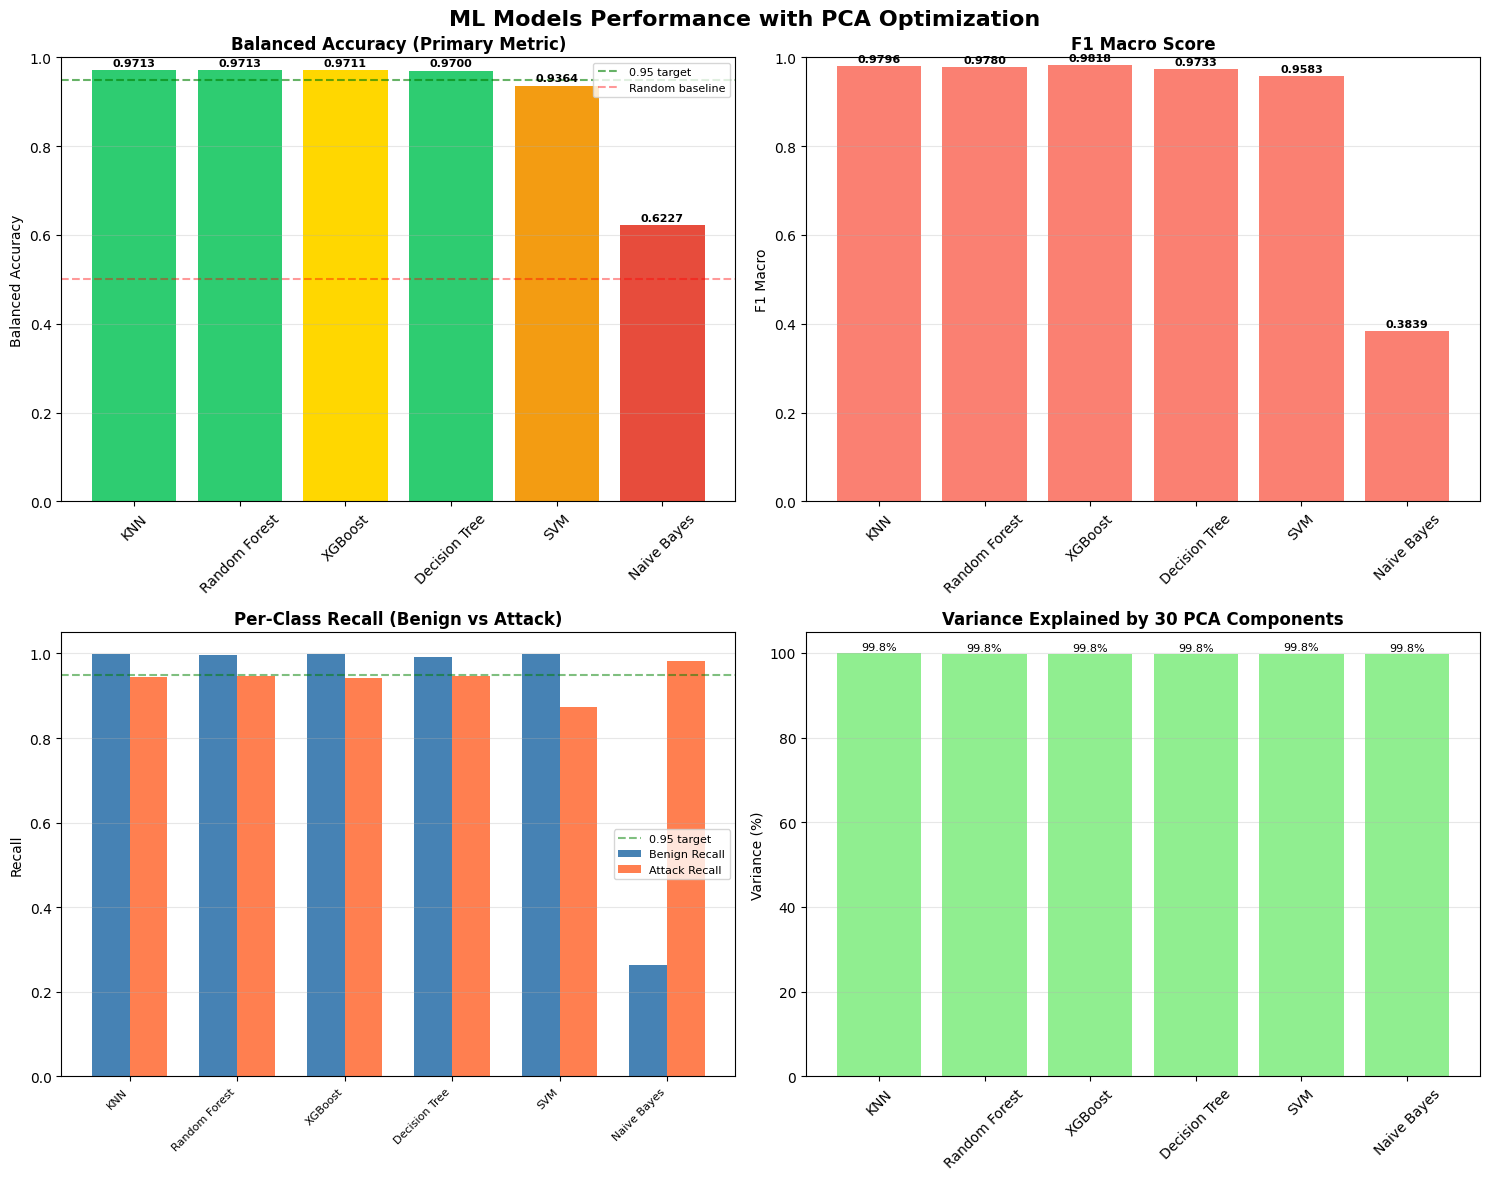


💾 Chart saved: performance_comparison_pca.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('ML Models Performance with PCA Optimization', fontsize=16, fontweight='bold')

model_names = results_df['Model'].tolist()

# 1. Balanced Accuracy
ax1 = axes[0, 0]
colors_ba = ['gold' if m == 'XGBoost' else
             '#2ecc71' if results_df.loc[results_df['Model']==m, 'Balanced Accuracy'].values[0] >= 0.95 else
             '#f39c12' if results_df.loc[results_df['Model']==m, 'Balanced Accuracy'].values[0] >= 0.90 else
             '#e74c3c' for m in model_names]
ax1.bar(model_names, results_df['Balanced Accuracy'], color=colors_ba)
ax1.set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
ax1.set_ylabel('Balanced Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=0.95, color='green', linestyle='--', alpha=0.6, label='0.95 target')
ax1.axhline(y=0.5,  color='red',   linestyle='--', alpha=0.4, label='Random baseline')
ax1.legend(fontsize=8)
for i, v in enumerate(results_df['Balanced Accuracy']):
    ax1.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 2. F1 Macro
ax2 = axes[0, 1]
ax2.bar(model_names, results_df['F1 Macro'], color='salmon')
ax2.set_title('F1 Macro Score', fontweight='bold')
ax2.set_ylabel('F1 Macro')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['F1 Macro']):
    ax2.text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3. Per-Class Recall
ax3 = axes[1, 0]
x     = range(len(model_names))
width = 0.35
ax3.bar([i - width/2 for i in x], results_df['Benign Recall'], width,
        label='Benign Recall', color='steelblue')
ax3.bar([i + width/2 for i in x], results_df['Attack Recall'], width,
        label='Attack Recall', color='coral')
ax3.set_title('Per-Class Recall (Benign vs Attack)', fontweight='bold')
ax3.set_ylabel('Recall')
ax3.set_ylim(0, 1.05)
ax3.set_xticks(list(x))
ax3.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax3.axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='0.95 target')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# 4. Variance Explained
ax4 = axes[1, 1]
ax4.bar(model_names, results_df['Variance %'], color='lightgreen')
ax4.set_title(f'Variance Explained by {N_COMPONENTS} PCA Components', fontweight='bold')
ax4.set_ylabel('Variance (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Variance %']):
    ax4.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_MODEL_DIR, 'performance_comparison_pca.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n💾 Chart saved: performance_comparison_pca.png")

## 🔟 PCA Analysis

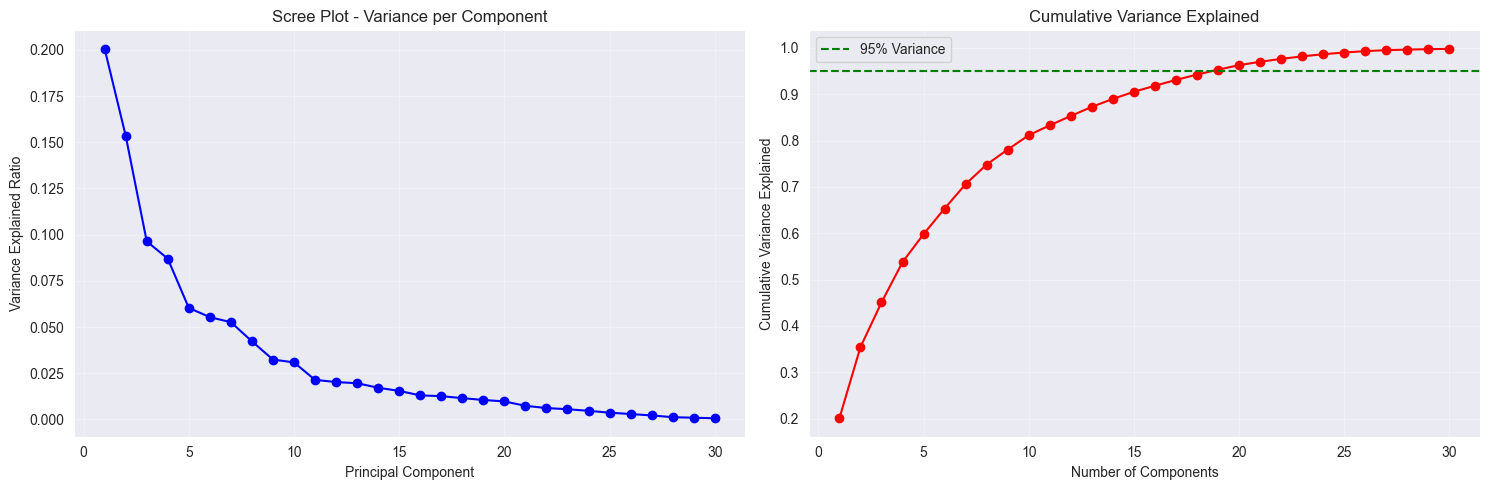


📊 PCA Analysis:
   Components: 30
   Total variance explained: 99.77%
   Top 5 components explain: 59.79%
   Top 10 components explain: 81.14%


In [ ]:
# Analyze PCA components (using XGBoost's PCA as example)
if 'XGBoost' in pca_transformers:
    pca = pca_transformers['XGBoost']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Scree plot - variance per component
    ax1 = axes[0]
    ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
             pca.explained_variance_ratio_, 'bo-')
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Variance Explained Ratio')
    ax1.set_title('Scree Plot - Variance per Component')
    ax1.grid(True, alpha=0.3)
    
    # 2. Cumulative variance
    ax2 = axes[1]
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    ax2.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
    ax2.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Variance Explained')
    ax2.set_title('Cumulative Variance Explained')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_MODEL_DIR, 'pca_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 PCA Analysis:")
    print(f"   Components: {len(pca.explained_variance_ratio_)}")
    print(f"   Total variance explained: {cumsum[-1]*100:.2f}%")
    print(f"   Top 5 components explain: {cumsum[4]*100:.2f}%")
    print(f"   Top 10 components explain: {cumsum[9]*100:.2f}%")